## DATASET: BTCUSDT

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, RocCurveDisplay
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

from xgboost import XGBClassifier

pd.set_option('display.max_columns', 200)


## 1) Load data & resample to 1H candles

In [2]:
DATA_PATH = r"C:/Users/jobin/Desktop/ML Project sep/data/BYBIT_BTCUSDT_15m.csv"  # change if needed

df15 = pd.read_csv(DATA_PATH)

# Parse time, sort, index
df15['Datetime'] = pd.to_datetime(df15['Datetime'], utc=False)
df15 = df15.sort_values('Datetime').set_index('Datetime')

print("15m coverage:", df15.index.min(), "->", df15.index.max())
print("15m shape:", df15.shape)
df15.head()


15m coverage: 2020-03-25 16:00:00 -> 2026-01-22 17:00:00
15m shape: (204389, 6)


,Open,High,Low,Close,Volume,Turnover
Datetime,,,,,,
2020-03-25 16:00:00,6500.0,6500.0,6500.0,6500.0,0.002,13.0000
2020-03-25 16:15:00,6500.0,6591.5,6500.0,6591.5,0.002,13.1830
2020-03-25 16:30:00,6591.5,6622.5,6585.5,6590.5,37.803,249140.6715
2020-03-25 16:45:00,6590.5,6628.5,6588.5,6618.0,141.338,935374.8840
2020-03-25 17:00:00,6618.0,6618.0,6457.5,6499.5,120.703,784509.1485


In [4]:
# Resample to 1H
agg = {
    'Open': 'first',
    'High': 'max',
    'Low': 'min',
    'Close': 'last',
    'Volume': 'sum',
    'Turnover': 'sum'
}

df = df15.resample('1h').agg(agg).dropna()

print("1H coverage:", df.index.min(), "->", df.index.max())
print("1H shape:", df.shape)
df.head()


1H coverage: 2020-03-25 16:00:00 -> 2026-01-22 17:00:00
1H shape: (51098, 6)


,Open,High,Low,Close,Volume,Turnover
Datetime,,,,,,
2020-03-25 16:00:00,6500.0,6628.5,6500.0,6618.0,179.145,1.184542e+06
2020-03-25 17:00:00,6618.0,6618.0,6457.5,6519.5,497.451,3.241120e+06
2020-03-25 18:00:00,6519.5,6618.5,6507.0,6598.0,553.200,3.642741e+06
2020-03-25 19:00:00,6598.0,6745.5,6516.0,6591.0,427.948,2.821253e+06
2020-03-25 20:00:00,6591.0,6662.0,6580.0,6641.0,32.769,2.166638e+05


## 2) Quick EDA (Exploratory Data Analysis)

To check:
- Missing values
- Price and volatility regimes
- Return distribution (fat tails are typical in crypto)


Missing values per column:


Open        0
High        0
Low         0
Close       0
Volume      0
Turnover    0
dtype: int64

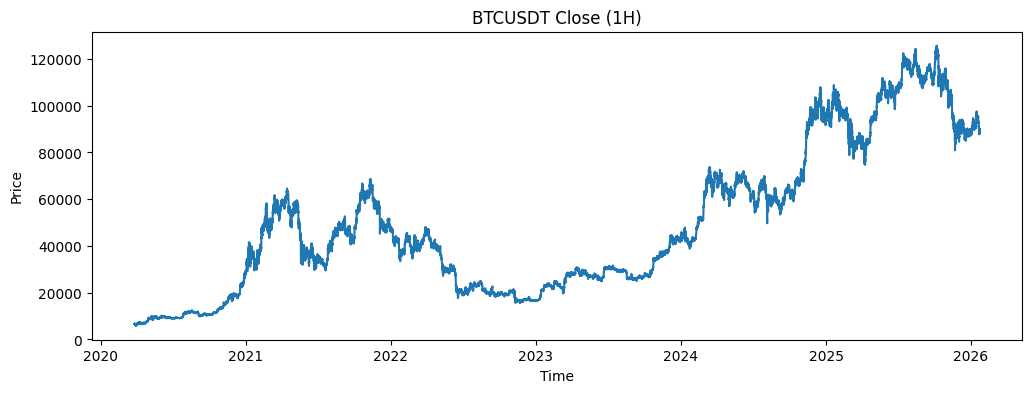

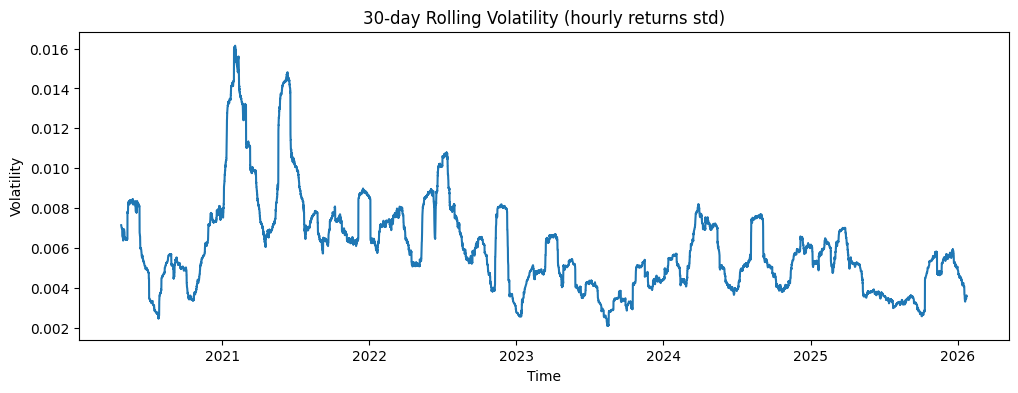

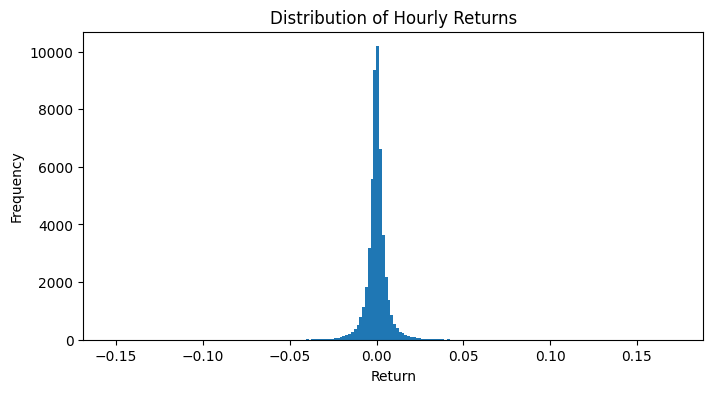

In [5]:
print("Missing values per column:")
display(df.isna().sum())

close = df['Close']
ret1 = close.pct_change()

# 30-day rolling volatility of hourly returns
vol_30d = ret1.rolling(24*30).std()

plt.figure(figsize=(12,4))
plt.plot(close)
plt.title("BTCUSDT Close (1H)")
plt.xlabel("Time")
plt.ylabel("Price")
plt.show()

plt.figure(figsize=(12,4))
plt.plot(vol_30d)
plt.title("30-day Rolling Volatility (hourly returns std)")
plt.xlabel("Time")
plt.ylabel("Volatility")
plt.show()

plt.figure(figsize=(8,4))
plt.hist(ret1.dropna(), bins=200)
plt.title("Distribution of Hourly Returns")
plt.xlabel("Return")
plt.ylabel("Frequency")
plt.show()


## 3) Target definition (binary direction)

In [6]:
df_target = df.copy()
df_target['y'] = (df_target['Close'].shift(-1) > df_target['Close']).astype(int)
df_target = df_target.iloc[:-1]

display(df_target['y'].value_counts())
display(df_target['y'].value_counts(normalize=True).rename('class_ratio'))
df_target.head()


y
1    25983
0    25114
Name: count, dtype: int64

y
1    0.508503
0    0.491497
Name: class_ratio, dtype: float64

,Open,High,Low,Close,Volume,Turnover,y
Datetime,,,,,,,
2020-03-25 16:00:00,6500.0,6628.5,6500.0,6618.0,179.145,1.184542e+06,0
2020-03-25 17:00:00,6618.0,6618.0,6457.5,6519.5,497.451,3.241120e+06,1
2020-03-25 18:00:00,6519.5,6618.5,6507.0,6598.0,553.200,3.642741e+06,0
2020-03-25 19:00:00,6598.0,6745.5,6516.0,6591.0,427.948,2.821253e+06,1
2020-03-25 20:00:00,6591.0,6662.0,6580.0,6641.0,32.769,2.166638e+05,1


## 4) Feature engineering (rates of change % + technical signals)

In [7]:
def rsi(series: pd.Series, period: int = 14) -> pd.Series:
    """RSI using exponentially weighted averages (stable and common)."""
    delta = series.diff()
    gain = delta.clip(lower=0)
    loss = (-delta).clip(lower=0)

    avg_gain = gain.ewm(alpha=1/period, adjust=False).mean()
    avg_loss = loss.ewm(alpha=1/period, adjust=False).mean()

    rs = avg_gain / (avg_loss + 1e-12)
    return 100 - (100 / (1 + rs))


def macd(series: pd.Series, fast: int = 12, slow: int = 26, signal: int = 9):
    ema_fast = series.ewm(span=fast, adjust=False).mean()
    ema_slow = series.ewm(span=slow, adjust=False).mean()
    macd_line = ema_fast - ema_slow
    signal_line = macd_line.ewm(span=signal, adjust=False).mean()
    hist = macd_line - signal_line
    return macd_line, signal_line, hist


def bollinger_z(series: pd.Series, window: int = 20, n_std: float = 2.0) -> pd.Series:
    ma = series.rolling(window).mean()
    sd = series.rolling(window).std()
    upper = ma + n_std * sd
    lower = ma - n_std * sd
    # z-score relative to midline scaled by sd
    z = (series - ma) / (sd + 1e-12)
    return z


def atr(high: pd.Series, low: pd.Series, close: pd.Series, period: int = 14) -> pd.Series:
    prev_close = close.shift(1)
    tr = pd.concat([
        (high - low),
        (high - prev_close).abs(),
        (low - prev_close).abs()
    ], axis=1).max(axis=1)
    return tr.ewm(alpha=1/period, adjust=False).mean()


def make_features(df_in: pd.DataFrame, lags: int = 24) -> pd.DataFrame:
    """Create rate-of-change features + technical indicators + lag features.

    lags: how many previous steps (hours) to include explicitly as lag features.
    """
    d = df_in.copy()

    # Rate-of-change (%)
    d['ret_close'] = d['Close'].pct_change()
    d['ret_open']  = d['Open'].pct_change()
    d['ret_high']  = d['High'].pct_change()
    d['ret_low']   = d['Low'].pct_change()

    d['vol_chg'] = d['Volume'].pct_change()
    d['turn_chg'] = d['Turnover'].pct_change()

    # Candle geometry as % of close (scale-free)
    d['hl_range_pct'] = (d['High'] - d['Low']) / d['Close']
    d['oc_body_pct']  = (d['Close'] - d['Open']) / d['Close']

    # Rolling stats on returns (multiple horizons)
    for w in [6, 12, 24, 48, 72, 168]:  # 6h, 12h, 1d, 2d, 3d, 1w
        d[f'ret_mean_{w}'] = d['ret_close'].rolling(w).mean()
        d[f'ret_std_{w}']  = d['ret_close'].rolling(w).std()
        d[f'mom_{w}']      = (1 + d['ret_close']).rolling(w).apply(np.prod, raw=True) - 1

    # Technical indicators (computed on close)
    d['rsi_14'] = rsi(d['Close'], 14)
    macd_line, signal_line, hist = macd(d['Close'], 12, 26, 9)
    d['macd'] = macd_line
    d['macd_signal'] = signal_line
    d['macd_hist'] = hist
    d['bb_z_20'] = bollinger_z(d['Close'], 20, 2.0)
    d['atr_14_pct'] = atr(d['High'], d['Low'], d['Close'], 14) / d['Close']

    # Lag features for ret_close (explicit lookback window)
    for i in range(1, lags + 1):
        d[f'ret_lag_{i}'] = d['ret_close'].shift(i)
        d[f'vol_lag_{i}'] = d['vol_chg'].shift(i)

    # Drop raw absolute prices to enforce "rate-of-change" preference
    drop_cols = ['Open', 'High', 'Low', 'Close', 'Volume', 'Turnover']
    d = d.drop(columns=drop_cols)

    # Clean infinities from pct_change
    d = d.replace([np.inf, -np.inf], np.nan)

    return d


In [8]:
# Build feature table (default lookback: 24 hours)
LAGS = 24
X_feat = make_features(df_target.drop(columns=['y']), lags=LAGS)
feat = X_feat.copy()
feat['y'] = df_target['y']

feat = feat.dropna()

print("Feature table shape:", feat.shape)
feat.head()


Feature table shape: (50929, 81)


,ret_close,ret_open,ret_high,ret_low,vol_chg,turn_chg,hl_range_pct,oc_body_pct,ret_mean_6,ret_std_6,mom_6,ret_mean_12,ret_std_12,mom_12,ret_mean_24,ret_std_24,mom_24,ret_mean_48,ret_std_48,mom_48,ret_mean_72,ret_std_72,mom_72,ret_mean_168,ret_std_168,mom_168,rsi_14,macd,macd_signal,macd_hist,bb_z_20,atr_14_pct,ret_lag_1,vol_lag_1,ret_lag_2,vol_lag_2,ret_lag_3,vol_lag_3,ret_lag_4,vol_lag_4,ret_lag_5,vol_lag_5,ret_lag_6,vol_lag_6,ret_lag_7,vol_lag_7,ret_lag_8,vol_lag_8,ret_lag_9,vol_lag_9,ret_lag_10,vol_lag_10,ret_lag_11,vol_lag_11,ret_lag_12,vol_lag_12,ret_lag_13,vol_lag_13,ret_lag_14,vol_lag_14,ret_lag_15,vol_lag_15,ret_lag_16,vol_lag_16,ret_lag_17,vol_lag_17,ret_lag_18,vol_lag_18,ret_lag_19,vol_lag_19,ret_lag_20,vol_lag_20,ret_lag_21,vol_lag_21,ret_lag_22,vol_lag_22,ret_lag_23,vol_lag_23,ret_lag_24,vol_lag_24,y
Datetime,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2020-04-01 16:00:00,-0.003252,0.001748,0.000317,0.001358,-0.088711,-0.089392,0.006765,-0.003263,-0.001025,0.003752,-0.006169,-0.001640,0.007588,-0.019814,-0.000516,0.006623,-0.012806,-0.000065,0.006779,-0.004200,0.000336,0.007542,0.022376,-0.000277,0.008105,-0.050695,40.918036,-28.139173,-19.184556,-8.954617,-1.065285,0.008863,0.001748,-0.063896,0.000159,-0.034904,-0.004195,-0.019089,0.004452,-0.049055,-0.005062,-0.077148,-0.004410,0.174942,0.000473,0.152891,0.006422,-0.165391,0.002145,-0.317515,0.004309,-0.154555,-0.022467,0.338546,-0.002645,-0.105830,-0.003721,0.376442,-0.003476,-0.326595,0.006062,0.210723,-0.003871,0.039343,0.008195,-0.105223,-0.004042,0.088793,-0.000621,-0.265932,-0.003715,0.027292,0.002327,-0.062670,0.012727,0.558921,0.000079,-0.163667,-0.009725,0.154870,0
2020-04-01 17:00:00,-0.008516,-0.003252,0.003963,-0.013407,1.774615,1.753854,0.024322,-0.008589,-0.001601,0.004652,-0.009619,-0.000477,0.004578,-0.005826,-0.000874,0.006819,-0.021290,-0.000327,0.006859,-0.016655,0.000319,0.007560,0.021148,-0.000239,0.008051,-0.044559,35.635198,-33.253432,-21.998331,-11.255100,-1.607810,0.010038,-0.003252,-0.088711,0.001748,-0.063896,0.000159,-0.034904,-0.004195,-0.019089,0.004452,-0.049055,-0.005062,-0.077148,-0.004410,0.174942,0.000473,0.152891,0.006422,-0.165391,0.002145,-0.317515,0.004309,-0.154555,-0.022467,0.338546,-0.002645,-0.105830,-0.003721,0.376442,-0.003476,-0.326595,0.006062,0.210723,-0.003871,0.039343,0.008195,-0.105223,-0.004042,0.088793,-0.000621,-0.265932,-0.003715,0.027292,0.002327,-0.062670,0.012727,0.558921,0.000079,-0.163667,0
2020-04-01 18:00:00,-0.001284,-0.008516,-0.014527,0.003478,-0.451544,-0.452685,0.006108,-0.001286,-0.002557,0.003639,-0.015275,-0.000943,0.004324,-0.011363,-0.001458,0.006173,-0.034831,-0.000363,0.006860,-0.018383,0.000294,0.007563,0.019335,-0.000318,0.007995,-0.057139,34.909400,-37.519550,-25.102575,-12.416975,-1.513579,0.009769,-0.008516,1.774615,-0.003252,-0.088711,0.001748,-0.063896,0.000159,-0.034904,-0.004195,-0.019089,0.004452,-0.049055,-0.005062,-0.077148,-0.004410,0.174942,0.000473,0.152891,0.006422,-0.165391,0.002145,-0.317515,0.004309,-0.154555,-0.022467,0.338546,-0.002645,-0.105830,-0.003721,0.376442,-0.003476,-0.326595,0.006062,0.210723,-0.003871,0.039343,0.008195,-0.105223,-0.004042,0.088793,-0.000621,-0.265932,-0.003715,0.027292,0.002327,-0.062670,0.012727,0.558921,0
2020-04-01 19:00:00,0.000000,-0.001284,-0.001843,-0.007496,0.473281,0.469760,0.011734,0.000000,-0.001858,0.003664,-0.011127,-0.001122,0.004228,-0.013479,-0.001555,0.006129,-0.037071,-0.000288,0.006843,-0.014807,0.000257,0.007557,0.016586,-0.000312,0.007995,-0.056137,34.909400,-40.434376,-28.168935,-12.265441,-1.382927,0.009910,-0.001284,-0.451544,-0.008516,1.774615,-0.003252,-0.088711,0.001748,-0.063896,0.000159,-0.034904,-0.004195,-0.019089,0.004452,-0.049055,-0.005062,-0.077148,-0.004410,0.174942,0.000473,0.152891,0.006422,-0.165391,0.002145,-0.317515,0.004309,-0.154555,-0.022467,0.338546,-0.002645,-0.105830,-0.003721,0.376442,-0.003476,-0.326595,0.006062,0.210723,-0.003871,0.039343,0.008195,-0.105223,

## 5) Train/Test split (last 1 year as test)

In [9]:
end_time = feat.index.max()
test_start = end_time - pd.Timedelta(days=365)

train_df = feat[feat.index < test_start]
test_df  = feat[feat.index >= test_start]

print("Train:", train_df.index.min(), "->", train_df.index.max(), train_df.shape)
print("Test :", test_df.index.min(),  "->", test_df.index.max(),  test_df.shape)

X_train = train_df.drop(columns=['y'])
y_train = train_df['y']

X_test = test_df.drop(columns=['y'])
y_test = test_df['y']


Train: 2020-04-01 16:00:00 -> 2025-01-22 15:00:00 (42168, 81)
Test : 2025-01-22 16:00:00 -> 2026-01-22 16:00:00 (8761, 81)


## 6) Evaluation helper

In [10]:
def print_cm(cm):
    tn, fp, fn, tp = cm.ravel()
    print(f"TN={tn:,}  FP={fp:,}")
    print(f"FN={fn:,}  TP={tp:,}")

def eval_classifier(name, model, Xtr, ytr, Xte, yte):
    model.fit(Xtr, ytr)
    pred = model.predict(Xte)

    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(Xte)[:, 1]
    else:
        proba = None

    metrics = {
        "model": name,
        "accuracy": accuracy_score(yte, pred),
        "balanced_acc": balanced_accuracy_score(yte, pred),
        "precision": precision_score(yte, pred, zero_division=0),
        "recall": recall_score(yte, pred, zero_division=0),
        "f1": f1_score(yte, pred, zero_division=0),
        "roc_auc": roc_auc_score(yte, proba) if proba is not None else np.nan
    }

    return metrics, confusion_matrix(yte, pred), proba


## 7) Base model (reference): Logistic Regression

,accuracy,balanced_acc,precision,recall,f1,roc_auc
model,,,,,,
LogReg (baseline),0.516836,0.517127,0.523419,0.489722,0.50601,0.516589


TN=2,360  FP=1,974
FN=2,259  TP=2,168


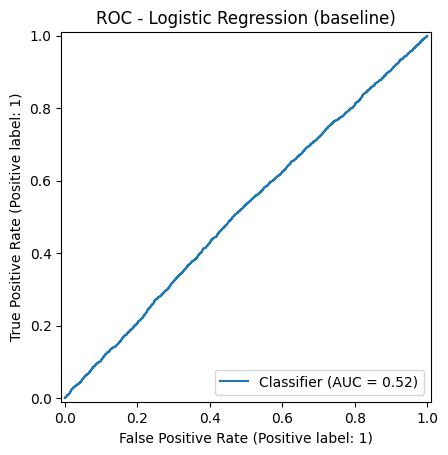

In [11]:
base_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=3000, n_jobs=-1, class_weight="balanced"))
])

m_lr, cm_lr, proba_lr = eval_classifier("LogReg (baseline)", base_lr, X_train, y_train, X_test, y_test)
display(pd.DataFrame([m_lr]).set_index("model"))
print_cm(cm_lr)

if proba_lr is not None:
    RocCurveDisplay.from_predictions(y_test, proba_lr)
    plt.title("ROC - Logistic Regression (baseline)")
    plt.show()


## 8) Stronger models (initial, untuned)

We test models that capture nonlinear interactions:
- Random Forest
- Histogram Gradient Boosting (sklearn)
- XGBoost

We keep a single held-out test set (last year) for the final comparison.


In [12]:
models = []

rf = RandomForestClassifier(
    n_estimators=500,
    min_samples_leaf=25,
    n_jobs=-1,
    class_weight="balanced_subsample",
    random_state=42
)
models.append(("RandomForest (untuned)", rf))

hgb = HistGradientBoostingClassifier(
    max_depth=6,
    learning_rate=0.05,
    max_iter=400,
    random_state=42
)
models.append(("HistGB (untuned)", hgb))

xgb = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    n_estimators=600,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1
)
models.append(("XGBoost (untuned)", xgb))

results = []
cms = {}
probas = {}

for name, model in models:
    m, cm, proba = eval_classifier(name, model, X_train, y_train, X_test, y_test)
    results.append(m)
    cms[name] = cm
    probas[name] = proba

results_df = pd.DataFrame([m_lr] + results).set_index("model").sort_values("roc_auc", ascending=False)
results_df


  File "c:\Users\jobin\anaconda3\envs\btc_env\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\jobin\anaconda3\envs\btc_env\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\jobin\anaconda3\envs\btc_env\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\jobin\anaconda3\envs\btc_env\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\jobin\anaconda3\envs\btc_env\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

,accuracy,balanced_acc,precision,recall,f1,roc_auc
model,,,,,,
RandomForest (untuned),0.518206,0.518138,0.523209,0.524509,0.523858,0.524874
XGBoost (untuned),0.513298,0.512923,0.517374,0.548227,0.532354,0.521218
HistGB (untuned),0.515809,0.515124,0.518698,0.579625,0.547472,0.518266
LogReg (baseline),0.516836,0.517127,0.523419,0.489722,0.506010,0.516589


In [13]:
for k, cm in cms.items():
    print("\n===", k, "===")
    print_cm(cm)



=== RandomForest (untuned) ===
TN=2,218  FP=2,116
FN=2,105  TP=2,322

=== HistGB (untuned) ===
TN=1,953  FP=2,381
FN=1,861  TP=2,566

=== XGBoost (untuned) ===
TN=2,070  FP=2,264
FN=2,000  TP=2,427


## 9) Improve metrics: tune the best candidate using time-series CV 


In [15]:
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from xgboost import XGBClassifier
import numpy as np

tscv = TimeSeriesSplit(n_splits=5)

xgb_base = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

param_dist = {
    "n_estimators": [200, 400, 600, 800],
    "learning_rate": [0.01, 0.03, 0.05, 0.08],
    "max_depth": [3, 4, 5, 6],
    "subsample": [0.7, 0.85, 1.0],
    "colsample_bytree": [0.7, 0.85, 1.0],
    "reg_lambda": [0.5, 1.0, 2.0]
}

rs = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=30,              # only 30 combinations
    scoring="roc_auc",
    cv=tscv,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

rs.fit(X_train, y_train)

print("Best CV ROC-AUC:", rs.best_score_)
print("Best params:", rs.best_params_)

best_xgb = rs.best_estimator_


Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best CV ROC-AUC: 0.54291356088911
Best params: {'subsample': 0.85, 'reg_lambda': 2.0, 'n_estimators': 400, 'max_depth': 4, 'learning_rate': 0.01, 'colsample_bytree': 0.85}


### Evaluate tuned XGBoost on the last-year test set

,accuracy,balanced_acc,precision,recall,f1,roc_auc
model,,,,,,
XGBoost (tuned),0.5117,0.511104,0.515288,0.567201,0.54,0.5185


TN=1,972  FP=2,362
FN=1,916  TP=2,511


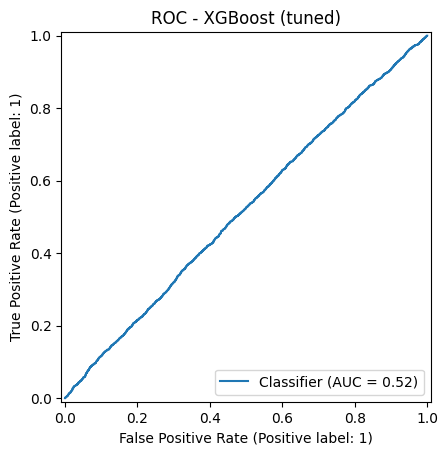

,accuracy,balanced_acc,precision,recall,f1,roc_auc
model,,,,,,
RandomForest (untuned),0.518206,0.518138,0.523209,0.524509,0.523858,0.524874
XGBoost (untuned),0.513298,0.512923,0.517374,0.548227,0.532354,0.521218
XGBoost (tuned),0.511700,0.511104,0.515288,0.567201,0.540000,0.518500
HistGB (untuned),0.515809,0.515124,0.518698,0.579625,0.547472,0.518266
LogReg (baseline),0.516836,0.517127,0.523419,0.489722,0.506010,0.516589


In [16]:
m_xgb_tuned, cm_xgb_tuned, proba_xgb_tuned = eval_classifier("XGBoost (tuned)", best_xgb, X_train, y_train, X_test, y_test)
display(pd.DataFrame([m_xgb_tuned]).set_index("model"))
print_cm(cm_xgb_tuned)

RocCurveDisplay.from_predictions(y_test, proba_xgb_tuned)
plt.title("ROC - XGBoost (tuned)")
plt.show()

# Combine results for the story (baseline -> untuned -> tuned)
results_all = pd.concat([
    results_df,
    pd.DataFrame([m_xgb_tuned]).set_index("model")
]).sort_values("roc_auc", ascending=False)

results_all


## 10) Feature importance (best model)


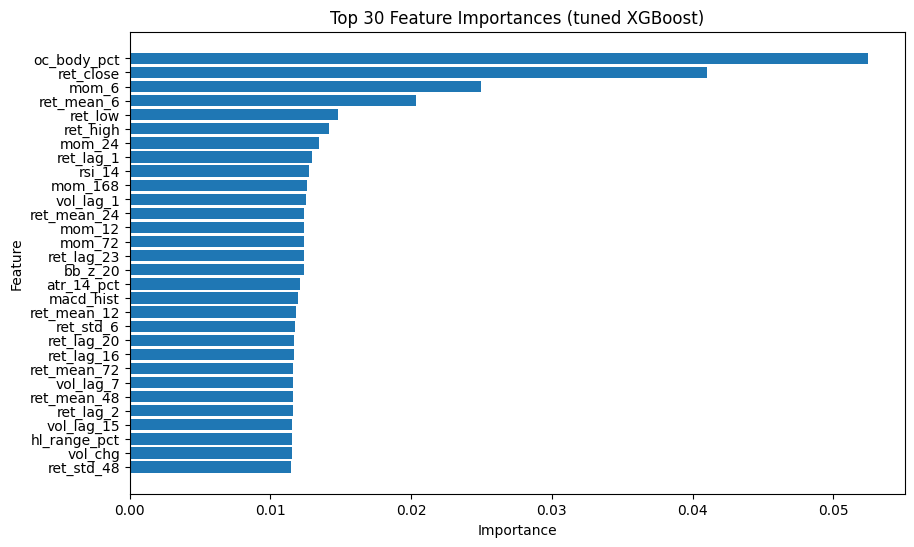

,importance
oc_body_pct,0.052452
ret_close,0.041047
mom_6,0.024984
ret_mean_6,0.020371
ret_low,0.014814
ret_high,0.014190
mom_24,0.013434
ret_lag_1,0.012937
rsi_14,0.012763
mom_168,0.012593


In [17]:
imp = pd.Series(best_xgb.feature_importances_, index=X_train.columns).sort_values(ascending=False)
top = imp.head(30)

plt.figure(figsize=(10,6))
plt.barh(top.index[::-1], top.values[::-1])
plt.title("Top 30 Feature Importances (tuned XGBoost)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

top.to_frame("importance").head(15)


## 11) Sensitivity analysis: lookback window length

In [18]:
def build_features_with_lags(lags: int) -> pd.DataFrame:
    Xf = make_features(df_target.drop(columns=['y']), lags=lags)
    f = Xf.copy()
    f['y'] = df_target['y']
    return f.dropna()

def eval_for_lags(lags_list, model):
    rows = []
    for L in lags_list:
        f = build_features_with_lags(L)

        end_time = f.index.max()
        test_start = end_time - pd.Timedelta(days=365)

        train = f[f.index < test_start]
        test  = f[f.index >= test_start]

        Xtr, ytr = train.drop(columns=['y']), train['y']
        Xte, yte = test.drop(columns=['y']), test['y']

        m, _, _ = eval_classifier(f"XGB_tuned_lags_{L}", model, Xtr, ytr, Xte, yte)
        rows.append({
            "lags": L,
            "accuracy": m["accuracy"],
            "balanced_acc": m["balanced_acc"],
            "f1": m["f1"],
            "roc_auc": m["roc_auc"]
        })
    return pd.DataFrame(rows).sort_values("roc_auc", ascending=False)

lags_to_try = [6, 12, 24, 48, 72]  # 6h .. 3d
lag_results = eval_for_lags(lags_to_try, best_xgb)
lag_results


,lags,accuracy,balanced_acc,f1,roc_auc
1,12,0.514781,0.514183,0.543051,0.523384
0,6,0.514667,0.514060,0.543287,0.522883
3,48,0.513982,0.513346,0.543818,0.519189
4,72,0.510216,0.509641,0.537757,0.519062
2,24,0.511700,0.511104,0.540000,0.518500


## 12) Best model and why

In [19]:
best_model_row = results_all.reset_index().sort_values("roc_auc", ascending=False).iloc[0]
best_model_row


model           RandomForest (untuned)
accuracy                      0.518206
balanced_acc                  0.518138
precision                     0.523209
recall                        0.524509
f1                            0.523858
roc_auc                       0.524874
Name: 0, dtype: object

In [3]:
print("Best model (by ROC-AUC on last-year test set):")
print(best_model_row['model'])

print("\nLookback (lags) sensitivity (top result):")
display(lag_results.head(1))


Best model (by ROC-AUC on last-year test set):


NameError: name 'best_model_row' is not defined